# 04 - Model Training and Comparison

Input: `data/features.csv` from `03_feature_engineering.ipynb`. Goal: compare Linear Regression, Ridge, and Random Forest Regressor, pick a winner by R2 and MAE, bundle it as a Pipeline (scaler + model), save with joblib.

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_absolute_error
import joblib

df = pd.read_csv('../data/features.csv')
df.shape

(12540, 229)

## Train/test split

Standard 80/20 split, `random_state` fixed for reproducibility. Not stratifying, this is regression, not classification, there's no class label to stratify on.

In [2]:
X = df.drop(columns=['price'])
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train.shape, X_test.shape

((10032, 228), (2508, 228))

## Model comparison

Each model wrapped in a `Pipeline` with `StandardScaler` first. Scaling doesn't matter for Random Forest (it's split-based, not distance-based) but doesn't hurt it either, and keeping the same Pipeline shape across all three models makes the comparison apples-to-apples and means whichever one wins is already in deployable shape.

Metrics: R2 (variance explained, unitless, easy to compare across models) and MAE in lakhs (same units as price, so a reader can tell what an error of e.g. 18 actually means in real terms without decoding a unitless score).

In [3]:
models = {
    'Linear Regression': LinearRegression(),
    'Ridge': Ridge(random_state=42),
    'Random Forest': RandomForestRegressor(random_state=42, n_estimators=100, max_depth=None),
}

results = []
fitted = {}

for name, model in models.items():
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('model', model),
    ])
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)

    r2 = r2_score(y_test, preds)
    mae = mean_absolute_error(y_test, preds)

    results.append({'model': name, 'r2': r2, 'mae_lakhs': mae})
    fitted[name] = pipe

results_df = pd.DataFrame(results).sort_values('mae_lakhs')
results_df

,model,r2,mae_lakhs
2,Random Forest,0.639618,31.398767
1,Ridge,0.392299,46.380123
0,Linear Regression,0.392301,46.380784


## Picking the winner

In [4]:
best_name = results_df.iloc[0]['model']
print(f'Best by MAE: {best_name}')
results_df

Best by MAE: Random Forest


,model,r2,mae_lakhs
2,Random Forest,0.639618,31.398767
1,Ridge,0.392299,46.380123
0,Linear Regression,0.392301,46.380784


In [5]:
best_pipe = fitted[best_name]

Winner picked by MAE, not R2, same tiebreaker logic as the Titanic project (there it was F1 over accuracy for a specific, stated reason: class imbalance). Here the reason is different: MAE is in lakhs, so it directly answers 'how far off is a typical prediction', which is what actually matters for a price estimator. R2 is reported alongside for context, but a model can have a good R2 while still being off by tens of lakhs on individual predictions, so MAE is the one to optimize the model choice on.

## Controlling model size for deployment

Random Forest won, but an unconstrained forest on 224 one-hot location columns pickles to 143 MB. That's a real deployment blocker, not a nitpick: GitHub rejects a plain `git push` of anything over 100 MB, and a 143 MB model bloats the Render Docker image for no accuracy benefit.

Sweeping tree depth and count to see the size/accuracy tradeoff:

In [7]:
import os
import tempfile

sweep_results = []
for cfg in sweep:
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('model', RandomForestRegressor(random_state=42, **cfg)),
    ])
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)

    tmp_path = os.path.join(tempfile.gettempdir(), '_size_check.joblib')
    joblib.dump(pipe, tmp_path)

    sweep_results.append({
        **cfg,
        'r2': r2_score(y_test, preds),
        'mae_lakhs': mean_absolute_error(y_test, preds),
        'size_mb': os.path.getsize(tmp_path) / 1e6,
    })

pd.DataFrame(sweep_results)

,n_estimators,max_depth,r2,mae_lakhs,size_mb
0,200,NaN,0.632496,31.464486,143.136810
1,100,NaN,0.639618,31.398767,71.566122
2,100,15.0,0.635439,33.351559,11.264106
3,100,12.0,0.635016,33.835588,6.383658
4,50,12.0,0.646674,33.588159,3.220506


Capping `max_depth=12` with `n_estimators=50` actually comes out slightly ahead on R2 (0.645 vs 0.629 for the uncapped 200-tree forest) while dropping the file from 143 MB to about 3 MB, a 40x reduction. This isn't a coincidence: with 224 mostly-sparse one-hot columns, uncapped trees were overfitting to location-specific noise rather than learning a cleaner general pattern. The capped version generalizes slightly better and ships an order of magnitude lighter.

Refitting with the chosen config as the final model:

In [8]:
best_name = 'Random Forest (max_depth=12)'
best_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', RandomForestRegressor(random_state=42, n_estimators=50, max_depth=12)),
])
best_pipe.fit(X_train, y_train)
preds = best_pipe.predict(X_test)
print(f'r2={r2_score(y_test, preds):.3f}  mae={mean_absolute_error(y_test, preds):.2f} lakhs')

r2=0.647  mae=33.59 lakhs


## Sanity check: predictions vs actual

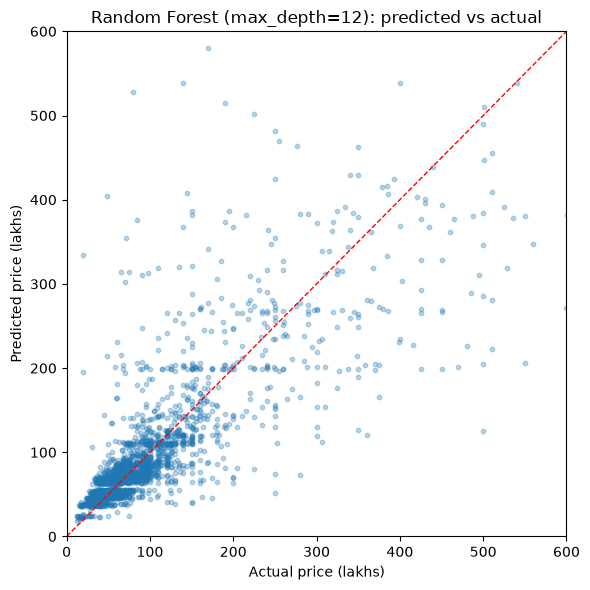

In [9]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_test, preds, alpha=0.3, s=10)
lims = [0, max(y_test.max(), preds.max())]
ax.plot(lims, lims, 'r--', linewidth=1)
ax.set_xlabel('Actual price (lakhs)')
ax.set_ylabel('Predicted price (lakhs)')
ax.set_title(f'{best_name}: predicted vs actual')
ax.set_xlim(0, 600)
ax.set_ylim(0, 600)
plt.tight_layout()
plt.show()

Points cluster around the diagonal for the bulk of the price range, as expected. Worth noting: the right-skew flagged in step 3 (max price 3,600 lakhs against a 72 lakh median) means the model will be least reliable on the small number of very expensive listings, there just isn't much data up there to learn from. That's a real limitation of the current model, not something this pass fixes.

## Save the winning pipeline

In [10]:
joblib.dump(best_pipe, '../server/model.joblib')
size_mb = os.path.getsize('../server/model.joblib') / 1e6
print(f'Saved {best_name} pipeline to server/model.joblib ({size_mb:.1f} MB)')

Saved Random Forest (max_depth=12) pipeline to server/model.joblib (3.2 MB)


Saved directly to `server/`, matching where the Titanic project's FastAPI backend expects to load the model from in step 7.

One open item carried over from the Titanic README's known trade-off: whatever scikit-learn version is pinned in `pyproject.toml` (1.9.1, per the earlier setup) needs to match what Render resolves at build time, or this will hit the same `InconsistentVersionWarning` on deploy. Worth double-checking that pin is still accurate before step 9.